In [1]:
import numpy as np
import networkx as nx
import mesa
import matplotlib.pyplot as plt
from enum import Enum
from mesa import Model, Agent
from mesa.space import NetworkGrid
from mesa.datacollection import DataCollector

In [2]:
class State(Enum):
    NON_SUSTAINABLE = 0
    TRANSITIONING = 1
    SUSTAINABLE = 2

In [3]:
class HouseholdAgent(Agent):
    def __init__(self, model):
        super().__init__(model)
        
        self.state = State.NON_SUSTAINABLE
        
        # Behavioral traits
        self.susceptibility = self.random.uniform(0.3, 1.0)   # openness--> fewer adopters then slower stransition
        self.entitlement = self.random.uniform(0.0, 1.0)      # resistance
        # -- We could use this one insead, making elites more resistant which is very relevant for high-income households
        # if self.model.G.degree[self.pos] > 10:
            #self.entitlement = 0.8
        self.habit = self.random.uniform(0.0, 1.0)            # inertia, if increased then system becomes sticky and harder to change
        

    def step(self):
        if self.state == State.NON_SUSTAINABLE:
            self.try_to_transition()
        elif self.state == State.TRANSITIONING:
            self.try_to_stabilize()

    def try_to_transition(self):
        # chance to go from one state to another
        neighbors = self.model.grid.get_neighbors(self.pos)
        if len(neighbors) == 0:
            return
        
        sustainable_neighbors = sum(1 for n in neighbors if n.state == State.SUSTAINABLE)
        
        social_norm = sustainable_neighbors / len(neighbors)

        # Adoption probability
        prob = (self.model.beta * social_norm * self.susceptibility * (1 - self.entitlement) * (1 - self.habit))

        if self.random.random() < prob:
            self.state = State.TRANSITIONING

    def try_to_stabilize(self):
        # chance to become fully sustainable
        stabilize_prob = self.model.gamma * (1 - self.habit)

        if self.random.random() < stabilize_prob:
            self.state = State.SUSTAINABLE

In [4]:
class AdoptionModel(Model):
    def __init__(self, N=400000, beta=0.3, gamma=0.1,  # ~400,000 households in Amsterdam
                 policy_shock_time=None, policy_type=None):  # optional policy intervention
        super().__init__()
        
        self.beta = beta      # strength of social norms
        self.gamma = gamma    # stabilization probability
        self.time = 0
        self.policy_shock_time = policy_shock_time  # time step at which policy is applied
        self.policy_type = policy_type              # string identifying the policy

        # --- Network ---
        self.G = nx.barabasi_albert_graph(N, 3)
        # type of network that has few elite hubs and many low nodes. We could try others like:
        # self.G = nx.erdos_renyi_graph(N, 0.1) #--> random society
        # self.G = nx.watts_strogatz_graph(N, 4, 0.1) #--> clustered communities where social norms gain importance
        self.grid = NetworkGrid(self.G)

        # --- Agent storage (Mesa 3 compatible) ---
        self.agent_list = []

        # --- Create agents ---
        for node in self.G.nodes():
            agent = HouseholdAgent(self)
            self.agent_list.append(agent)
            self.grid.place_agent(agent, node)

        # --- Initial condition: seed high-degree hub nodes as sustainable ---
        # Hubs have many connections → social norm signal spreads faster from them.
        # Rogers (1962) Diffusion of Innovations: early adopters tend to be more
        # connected and influential. In Barabási-Albert networks hubs are the natural
        # 'opinion leaders' whose behaviour is most visible to others.
        sorted_nodes = sorted(self.G.nodes(), key=lambda n: self.G.degree[n], reverse=True)
        hub_nodes = sorted_nodes[:400]  # top-0.1% by degree (~400 of 400,000 households)
        for node in hub_nodes:
            self.agent_list[node].state = State.SUSTAINABLE

        # --- Data collection ---
        self.datacollector = DataCollector(
            model_reporters={
                "Sustainable": lambda m: sum(a.state == State.SUSTAINABLE for a in m.agent_list),
                "Transitioning": lambda m: sum(a.state == State.TRANSITIONING for a in m.agent_list),
                "Non Sustainable": lambda m: sum(a.state == State.NON_SUSTAINABLE for a in m.agent_list),
            }
        )

    def apply_policy(self):
        """Apply a one-time policy shock at policy_shock_time.

        Policy options (set policy_type when creating the model):

        'carbon_tax'
            Increases beta (social pressure) by raising the perceived cost of
            non-sustainable behaviour. Based on: Pigou (1920); Stern (2007)
            'The Economics of Climate Change'; EU ETS literature.
            → self.beta += 0.15

        'awareness_campaign'
            Reduces entitlement of all agents (lowers resistance) by simulating
            a city-wide information campaign. Based on: Schultz et al. (2007)
            'The Constructive, Destructive, and Reconstructive Power of Social Norms'
            Psychological Science; Amsterdam's own 'Duurzaam Amsterdam' programme.
            → agent.entitlement *= 0.7  for all agents

        'habit_subsidy'
            Reduces habit inertia (e.g. free e-bike scheme, heat-pump subsidy).
            Based on: Dolan & Metcalfe (2013) 'Neighbors, knowledge and nudges';
            Dutch SDE++ subsidy literature; Verplanken & Wood (2006) on habit
            discontinuity.
            → agent.habit *= 0.6  for all agents

        'influencer_seeding'
            Forces the top-1% highest-degree nodes to State.SUSTAINABLE immediately,
            mimicking targeted outreach to community leaders / block captains.
            Based on: Valente (1995) 'Network Models of the Diffusion of Innovations';
            Centola (2010) 'The Spread of Behavior in an Online Social Network'
            Science 329(5996).
            → hub nodes set to SUSTAINABLE
        """
        if self.policy_type == 'carbon_tax':
            self.beta = min(1.0, self.beta + 0.15)

        elif self.policy_type == 'awareness_campaign':
            for agent in self.agent_list:
                agent.entitlement *= 0.7

        elif self.policy_type == 'habit_subsidy':
            for agent in self.agent_list:
                agent.habit *= 0.6

        elif self.policy_type == 'influencer_seeding':
            top1pct = sorted(self.G.nodes(), key=lambda n: self.G.degree[n], reverse=True)
            top1pct = top1pct[:max(1, len(top1pct) // 100)]
            for node in top1pct:
                self.agent_list[node].state = State.SUSTAINABLE

    def step(self):
        # Apply policy shock once at the specified time step
        if self.policy_shock_time is not None and self.time == self.policy_shock_time:
            self.apply_policy()

        # Collect data
        self.datacollector.collect(self)

        # Random activation
        np.random.shuffle(self.agent_list)

        for agent in self.agent_list:
            agent.step()

        self.time += 1

In [5]:
# Amsterdam: ~400,000 households (CBS 2023). Using representative sample for tractability.
# Full city: N=400_000; for fast runs use N=10_000 (scales proportionally)
#
# Policy options: policy_type='carbon_tax' | 'awareness_campaign' | 'habit_subsidy' | 'influencer_seeding'
# Set policy_shock_time to the step at which the intervention kicks in (e.g. 50)
#
# Examples:
# model = AdoptionModel(N=10_000, beta=0.25, gamma=0.05, policy_shock_time=50, policy_type='carbon_tax')
model = AdoptionModel(N=10_000, beta=0.25, gamma=0.05, policy_shock_time=25, policy_type='awareness_campaign')
# model = AdoptionModel(N=10_000, beta=0.25, gamma=0.05, policy_shock_time=50, policy_type='habit_subsidy')
# model = AdoptionModel(N=10_000, beta=0.25, gamma=0.05, policy_shock_time=50, policy_type='influencer_seeding')

#model = AdoptionModel(N=10_000, beta=0.25, gamma=0.05)  # baseline – no policy
# change beta --> social pressure, low = no adoption, high = adoption
# change gamma --> stabilization, low = people stay transitioning, high = fast transition

for _ in range(400):
    model.step()

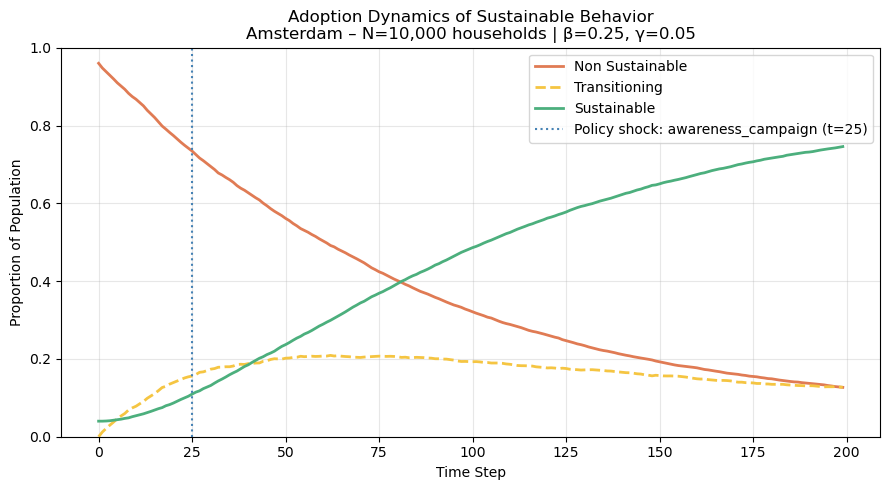

In [6]:
df = model.datacollector.get_model_vars_dataframe()

# Normalize to proportions
df_norm = df.div(df.sum(axis=1), axis=0)

# Line plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(df_norm.index, df_norm["Non Sustainable"],  label="Non Sustainable",  color="#e07b54", linewidth=2)
ax.plot(df_norm.index, df_norm["Transitioning"],    label="Transitioning",    color="#f5c542", linewidth=2, linestyle="--")
ax.plot(df_norm.index, df_norm["Sustainable"],      label="Sustainable",      color="#4caf7d", linewidth=2)

# Mark policy shock if one was applied
if model.policy_shock_time is not None:
    ax.axvline(model.policy_shock_time, color="steelblue", linestyle=":", linewidth=1.5,
               label=f"Policy shock: {model.policy_type} (t={model.policy_shock_time})")

ax.set_xlabel("Time Step")
ax.set_ylabel("Proportion of Population")
ax.set_title(f"Adoption Dynamics of Sustainable Behavior\n"
             f"Amsterdam – N={len(model.agent_list):,} households | "
             f"β={model.beta:.2f}, γ={model.gamma:.2f}")
ax.set_ylim(0, 1)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()